In [10]:
import this 

In [11]:
import pandas as pd


In [12]:
df=pd.read_csv('messy_dataset.csv')
df

,CustomerID,Age,State,Income,Purchases,LastPurchaseDate,Review,Churn
0,CUST001,40.0,CA,40000.0,0.0,NaN,NaN,NaN
1,CUST002,40.0,california,40000.0,1.0,NaN,NaN,NaN
2,CUST003,60.0,NY,40000.0,10.0,2021-13-40,NaN,N
3,CUST004,200.0,California,1000000.0,10.0,2021-13-40,Great product!,Y
4,CUST005,200.0,CA,40000.0,NaN,5/20/2021,Loved it!!!,Yes
...,...,...,...,...,...,...,...,...
95,CUST096,30.0,California,70000.0,10.0,2021-13-40,Ok,N
96,CUST097,25.0,CA,50000.0,NaN,2021-13-40,would buy again,NaN
97,CUST098,25.0,NaN,1000000.0,1.0,NaN,Great product!,N
98,CUST099,25.0,California,50000.0,3.0,NaN,Great product!,Y


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        100 non-null    object 
 1   Age               88 non-null     float64
 2   State             85 non-null     object 
 3   Income            83 non-null     float64
 4   Purchases         84 non-null     float64
 5   LastPurchaseDate  79 non-null     object 
 6   Review            77 non-null     object 
 7   Churn             76 non-null     object 
dtypes: float64(3), object(5)
memory usage: 6.4+ KB


Step 1: Load the "messy dataset" and explore the Data – Import the dataset into Phyton. Explore: How many rows and columns? Are their any potential problematic variables?

There are 8 columns, and 99 rows of data
, an there are potential problematic variables. 

Step 2: Identify columns with missing values and Decide: How to handle them? (e.g. drop the value, mean/median, mode, forward fill, etc)

There are columns with missing values: Age, income, Purchases, Last Purchase date, Review.

Step 3: Identify Invalid or Inconsistent Entries and Fix: The following variables: Age, State, Churn (e.g. Yes/No)
Last Purchase date and State both have inconsistencies in the data format.

Step 4: Detect and Handle Outliers – Inspect Income and Decide how to handle outliers.



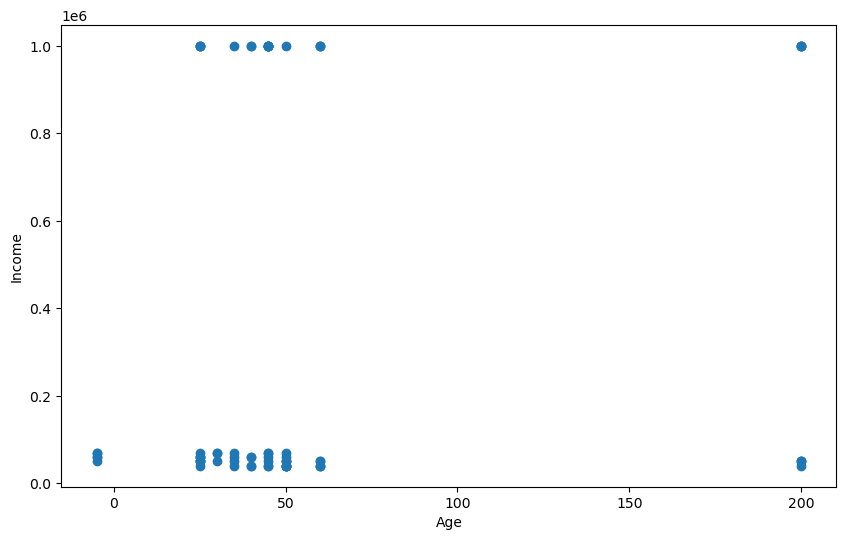

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(df['Age'], df['Income'])
plt.xlabel("Age")
plt.ylabel("Income")
plt.show()

there are outliers in age and income, i would handle this outlier by excluding it from the data set

Step 5: Working with Dates – Check LastPurchaseDate column and Convert
valid dates to daytime format



In [15]:
#viewing how many missing values there are for each column
df.isnull().sum()

CustomerID           0
Age                 12
State               15
Income              17
Purchases           16
LastPurchaseDate    21
Review              23
Churn               24
dtype: int64

In [16]:
from datetime import date
#convert null values to an early date that can be used as a placeholder
import pandas as pd
from datetime import datetime

df['LastPurchaseDate'] = pd.to_datetime(df['LastPurchaseDate'], errors='coerce', format='mixed')
df['LastPurchaseDate'] = df['LastPurchaseDate'].fillna(method='bfill')

df



C:\Users\preci\AppData\Local\Temp\ipykernel_26780\3681626350.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['LastPurchaseDate'] = df['LastPurchaseDate'].fillna(method='bfill')


,CustomerID,Age,State,Income,Purchases,LastPurchaseDate,Review,Churn
0,CUST001,40.0,CA,40000.0,0.0,2021-05-20,NaN,NaN
1,CUST002,40.0,california,40000.0,1.0,2021-05-20,NaN,NaN
2,CUST003,60.0,NY,40000.0,10.0,2021-05-20,NaN,N
3,CUST004,200.0,California,1000000.0,10.0,2021-05-20,Great product!,Y
4,CUST005,200.0,CA,40000.0,NaN,2021-05-20,Loved it!!!,Yes
...,...,...,...,...,...,...,...,...
95,CUST096,30.0,California,70000.0,10.0,NaT,Ok,N
96,CUST097,25.0,CA,50000.0,NaN,NaT,would buy again,NaN
97,CUST098,25.0,NaN,1000000.0,1.0,NaT,Great product!,N
98,CUST099,25.0,California,50000.0,3.0,NaT,Great product!,Y


In [17]:
#count null value for the data frame
df.isnull().sum()

CustomerID           0
Age                 12
State               15
Income              17
Purchases           16
LastPurchaseDate     8
Review              23
Churn               24
dtype: int64

Step 6: Explore the review column and Create a new binary feature called “PositiveReview” . If the answer contains “great”, “love”, “buy again” then assign =1, everything else assign=0.

In [19]:
#the review column has some missing values, so i fill them in with imputation
#flash fill review column

df['Review']=df['Review'].fillna(method= 'bfill')
df

C:\Users\preci\AppData\Local\Temp\ipykernel_26780\377190847.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Review']=df['Review'].fillna(method= 'bfill')


,CustomerID,Age,State,Income,Purchases,LastPurchaseDate,Review,Churn
0,CUST001,40.0,CA,40000.0,0.0,2021-05-20,Great product!,NaN
1,CUST002,40.0,california,40000.0,1.0,2021-05-20,Great product!,NaN
2,CUST003,60.0,NY,40000.0,10.0,2021-05-20,Great product!,N
3,CUST004,200.0,California,1000000.0,10.0,2021-05-20,Great product!,Y
4,CUST005,200.0,CA,40000.0,NaN,2021-05-20,Loved it!!!,Yes
...,...,...,...,...,...,...,...,...
95,CUST096,30.0,California,70000.0,10.0,NaT,Ok,N
96,CUST097,25.0,CA,50000.0,NaN,NaT,would buy again,NaN
97,CUST098,25.0,NaN,1000000.0,1.0,NaT,Great product!,N
98,CUST099,25.0,California,50000.0,3.0,NaT,Great product!,Y


In [21]:
#if the response is positive, mark it as 1, 0 if nuetral or negative
df['PositiveResponse'] = df['Review'].isin(['Great product!', 'Loved it!!!', 'would buy again']).astype(int)

df


,CustomerID,Age,State,Income,Purchases,LastPurchaseDate,Review,Churn,PositiveResponse
0,CUST001,40.0,CA,40000.0,0.0,2021-05-20,Great product!,NaN,1
1,CUST002,40.0,california,40000.0,1.0,2021-05-20,Great product!,NaN,1
2,CUST003,60.0,NY,40000.0,10.0,2021-05-20,Great product!,N,1
3,CUST004,200.0,California,1000000.0,10.0,2021-05-20,Great product!,Y,1
4,CUST005,200.0,CA,40000.0,NaN,2021-05-20,Loved it!!!,Yes,1
...,...,...,...,...,...,...,...,...,...
95,CUST096,30.0,California,70000.0,10.0,NaT,Ok,N,0
96,CUST097,25.0,CA,50000.0,NaN,NaT,would buy again,NaN,1
97,CUST098,25.0,NaN,1000000.0,1.0,NaT,Great product!,N,1
98,CUST099,25.0,California,50000.0,3.0,NaT,Great product!,Y,1


Favorite Food: Sushiiiii :)